# Go/No-Go 1 v3 Development Experiment

## tl;dr

v3 remains **NO-GO as a validated complexity metric**. The score has low triangle-count
confounding and every fixed-budget direction is positive, but the independent Validation
correlation with objective approximation difficulty is below the preregistered threshold.
This does not reject Mesh+URDF as the dataset format; it rejects this score revision.

## Context & Methods

The 142 eligible robot entities were split by product family into Development (80),
Validation (32), and sealed Final Holdout (30). Percentile transforms were fitted only on
Development. The geometry score is the equal mean of orientation distribution, local
curvature, and multiscale persistence modules. No learned feature weights are used.

The external target is fixed-budget mesh approximation difficulty at nominal 1k, 5k,
and 10k face budgets, computed from equal-weight percentile-normalized Chamfer,
Hausdorff, and normal errors. The target is not an input to the geometry score.

### Key Assumptions

- Product-family isolation is the unit of leakage control.
- A per-link minimum of 20 faces can make achieved faces slightly exceed the nominal
  robot-level budget; both values are retained.
- Validation is used once for this declared v3 decision. Final Holdout is not read.
- Expert blind ratings remain an auxiliary construct-validity check, not the source of weights.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
results = root / "results" / "v3"
summary = json.loads((results / "v3_summary.json").read_text(encoding="utf-8"))
split_summary = json.loads((results / "split_summary.json").read_text(encoding="utf-8"))
budget_summary = json.loads((results / "fixed_budget_summary.json").read_text(encoding="utf-8"))
scores = pd.read_csv(results / "v3_scores.csv")
errors = pd.read_csv(results / "fixed_budget_errors.csv")
assert not (scores.v3_split == "final_holdout").any()
assert not (errors.v3_split == "final_holdout").any()
summary["decision"]

'NO-GO'

## Data

The following cells audit split size, family separation, approximation coverage, and the
fact that Final Holdout was not touched.

In [2]:
pd.DataFrame({
    "check": ["Development entities", "Validation entities", "Final Holdout used",
              "Approximation rows", "Approximation failures"],
    "value": [summary["development_n"], summary["validation_n"],
              summary["final_holdout_touched"], budget_summary["n_rows"],
              budget_summary["rows_with_failures"]],
})

,check,value
0,Development entities,80
1,Validation entities,32
2,Final Holdout used,False
3,Approximation rows,336
4,Approximation failures,0


## Results

The preregistered primary threshold is Validation Spearman rho ≥ 0.60. Robustness requires
rho ≥ 0.85, triangle confounding requires |rho| < 0.30, and leave-one-module-out stability
requires rho ≥ 0.80.

In [3]:
checks = pd.DataFrame([
    {"criterion": key, "pass": value}
    for key, value in summary["criteria"].items()
])
checks

,criterion,pass
0,validation_objective_rho_gte_0.60,False
1,remesh_rho_gte_0.85,False
2,triangle_confound_abs_rho_lt_0.30,True
3,leave_one_module_out_rho_gte_0.80,False
4,all_budget_directions_positive,True


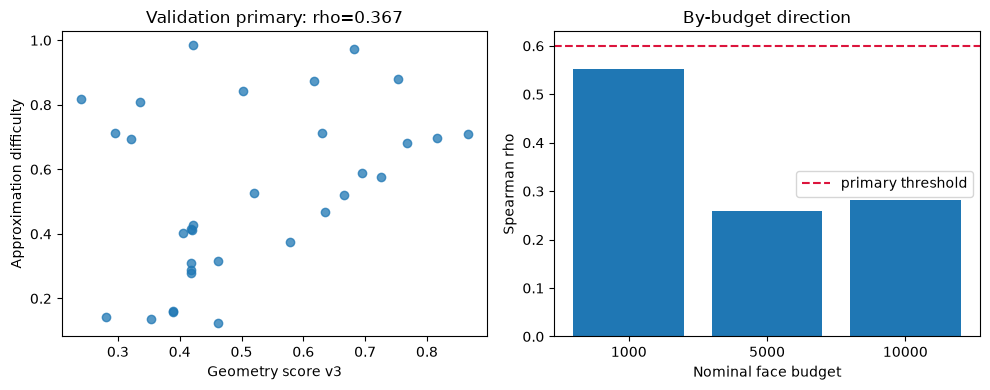

In [4]:
validation = scores.query("v3_split == 'validation'")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(validation.geometry_score_v3, validation.approximation_difficulty, alpha=.75)
axes[0].set(xlabel="Geometry score v3", ylabel="Approximation difficulty",
            title=f"Validation primary: rho={summary['validation_primary']['rho']:.3f}")
budget_rho = {k: v["rho"] for k, v in summary["validation_by_budget"].items()}
axes[1].bar(budget_rho.keys(), budget_rho.values())
axes[1].axhline(.60, color="crimson", linestyle="--", label="primary threshold")
axes[1].set(xlabel="Nominal face budget", ylabel="Spearman rho", title="By-budget direction")
axes[1].legend()
fig.tight_layout()
plt.show()

In [5]:
pd.DataFrame({
    "quantity": ["Validation primary rho", "1k-budget rho", "5k-budget rho",
                 "10k-budget rho", "Remesh 50% rho", "Remesh 25% rho",
                 "Triangle-count rho"],
    "value": [summary["validation_primary"]["rho"],
              summary["validation_by_budget"]["1000"]["rho"],
              summary["validation_by_budget"]["5000"]["rho"],
              summary["validation_by_budget"]["10000"]["rho"],
              summary["validation_remesh_stability"]["original_vs_50"]["rho"],
              summary["validation_remesh_stability"]["original_vs_25"]["rho"],
              summary["validation_triangle_confound"]["rho"]],
})

,quantity,value
0,Validation primary rho,0.366920
1,1k-budget rho,0.552540
2,5k-budget rho,0.259392
3,10k-budget rho,0.281200
4,Remesh 50% rho,0.781970
5,Remesh 25% rho,0.790802
6,Triangle-count rho,0.264722


## Takeaways

1. **Decision: NO-GO for score v3.** Validation rho is 0.367, below 0.60.
2. Triangle-count confounding passes (rho 0.265), so failure is not simply mesh density.
3. Approximation correlations are positive at all budgets, but decay from 0.553 at 1k to
   about 0.26–0.28 at 5k/10k; the descriptor captures coarse compression difficulty better
   than fine-detail difficulty.
4. Remesh stability (0.782/0.791) is improved but below 0.85, and omitting orientation
   changes rankings too much (rho 0.766).
5. Final Holdout remains sealed. A materially changed descriptor—not threshold relaxation
   or learned expert weights—is required before spending it.